In [ ]:
# la clé API: "xai-6utRpRrMllaPnw57PH7F2zggwXUpHo9d94mJFOhriwskrvjqvYdf7mVwhRofBkymxjL1PG26vKMXeAPg"
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

# 2.LLM

## 2.1 CELLULE 1 — Installation / imports

In [ ]:
# =========================
#  INSTALLATION GROQ SDK
# =========================

!pip install groq
import json

In [ ]:
# =========================
#  CONFIG GROQ API
# =========================

from groq import Groq

GROQ_API_KEY = "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"  # ⚠️ mets ta clé

client = Groq(api_key=GROQ_API_KEY)

## 2.2 Charger la transcription

In [ ]:
# =========================
#  CHARGEMENT TRANSCRIPTION
# =========================

FILE_PATH = "/content/ia04_extract.txt"  # adapte si besoin

def load_transcription(file_path: str) -> str:
    """
    Charge un fichier texte contenant la transcription d'un match.
    """
    with open(file_path, "r", encoding="utf-8") as f:
        text = f.read()
    return text


transcription = load_transcription(FILE_PATH)

print("===== TRANSCRIPTION =====")
print(transcription[:1000])  # aperçu

===== TRANSCRIPTION =====
Je pense qu'après le service de
Jean-Patri, on verra la rentrée du
capitaine Benjamin Tonyuti
pour terminer ce set.
Monstrueux ce bloc une nouvelle fois.
Nicolas Legof, vous parliez de vos
attentes il y a quelques instants. Pour
l'instant, il est impeccable.
Ouais. Surtout dans le domaine où on
l'attend. C'est-à-dire le domaine du
bloc.
C'est un domaine où il est très
performant. il l' été un tout petit peu
moins lors de la de la VNL, la Ligue des
Nations mais c'était l'ensemble de
l'équipe hein. Là je parle de Nicolas
Legof mais c'est vrai que l'ensemble de
l'équipe a été un petit peu moins
performante dans ce domaine du bloc. On
sait toute l'importance du bloc au
niveau international. Quand on sert
bien, il faut arriver à bloquer.
Et voilà le double changement qui a donc
été fait en deux temps. À la passe, on
passe d'Antoine Brésar à Benjamin
Bintoni.
Et au poste de pointue, vous avez vu
Jean-Patrie céder sa place à Théophor.
Oui, c'est bien de donner un pet

## 2.3 CONFIGURATION GROK (API) et mise en place du prompt

In [ ]:
# =========================
#  PROMPT SYSTEM GROK
# =========================

SYSTEM_PROMPT = """
Tu es un analyste expert de matchs de volley-ball.

Ton rôle est de transformer une transcription de match en JSON STRICT et d'évaluer les joueurs.

RÈGLES IMPORTANTES :
- Tu dois répondre UNIQUEMENT en JSON valide
- Aucun texte hors JSON
- Ne pas inventer de joueurs inexistants
- Si une info manque, mettre null ou 0
- Noter chaque joueur sur 20 selon 5 critères concrets

CRITÈRES DE NOTATION (0-20) :
1. "technique" : Basé sur le ratio (points + aces) / erreurs. Maîtrise du geste.
   - Formula: (points + aces*2) - (erreurs*2) = note/20
   
2. "defense" : Basé sur le nombre de blocks réussis et erreurs de défense.
   - Plus de blocks = plus haut score. Erreurs = baisse la note.
   - Formula: (blocks*3) - (erreurs) = note/20
   
3. "attitude" : Évalué par la cohérence et la récurrence des bonnes actions.
   - Si le joueur a peu d'erreurs = bonne attitude
   - Formula: 20 - (erreurs) = note/20
   
4. "physique" : Évalué par l'intensité et la fréquence des actions (points + aces + blocks).
   - Plus d'actions = meilleure condition physique
   - Formula: (points + aces + blocks) / 2 = note/20
   
5. "decision_tactique" : Évalué par l'efficacité des actions (points/total actions).
   - Si beaucoup de points avec peu d'erreurs = bonnes décisions
   - Formula: (points*2) / (points + erreurs + blocks) * 20 = note/20

FORMAT OBLIGATOIRE :

{
  "match_id": "string",
  "teams": {
    "A": "string",
    "B": "string"
  },
  "score": {
    "A": 0,
    "B": 0
  },
  "summary": "string",
  "players": [
    {
      "name": "string",
      "team": "string",
      "points": 0,
      "aces": 0,
      "blocks": 0,
      "errors": 0,
      "scores": {
        "technique": 0,
        "defense": 0,
        "attitude": 0,
        "physique": 0,
        "decision_tactique": 0
      },
      "final_score": 0,
      "notes": "string"
    }
  ],
  "key_events": ["string"]
}

INSTRUCTIONS SUPPLÉMENTAIRES :
- final_score = moyenne des 5 critères arrondie à 1 décimale
- notes : synthèse courte de la performance du joueur et ses points forts/faibles
- Être précis, structuré et cohérent dans l'analyse
- Les scores doivent refléter UNIQUEMENT ce qui est observé dans la transcription
"""

In [ ]:
import re

def extract_json(text: str) -> str:
    """
    Extrait le JSON depuis une réponse LLM.
    """
    match = re.search(r"\{.*\}", text, re.DOTALL)
    if match:
        return match.group(0)
    return None


def call_groq(transcription: str) -> dict:
    try:
        response = client.chat.completions.create(
            model="llama-3.1-8b-instant",
            messages=[
                {"role": "system", "content": SYSTEM_PROMPT},
                {"role": "user", "content": transcription}
            ],
            temperature=0.2
        )

        content = response.choices[0].message.content

        print("===== RAW OUTPUT =====")
        print(content)

        json_text = extract_json(content)

        if json_text is None:
            print(" Aucun JSON trouvé")
            return None

        return json.loads(json_text)

    except Exception as e:
        print(" Erreur :", e)
        return None

In [ ]:
# =========================
#  BASE DE DONNÉES JOUEURS
# =========================

PLAYERS_DB_PATH = "/content/players_db.json"


def load_players_db():
    """
    Charge la base de données des joueurs.
    Si elle n'existe pas, on la crée.
    """
    if not os.path.exists(PLAYERS_DB_PATH):
        return {}

    with open(PLAYERS_DB_PATH, "r", encoding="utf-8") as f:
        return json.load(f)


def save_players_db(db):
    """
    Sauvegarde la base de données des joueurs.
    """
    with open(PLAYERS_DB_PATH, "w", encoding="utf-8") as f:
        json.dump(db, f, indent=2, ensure_ascii=False)

In [ ]:
# =========================
#  UPDATE STATS JOUEURS
# =========================

def update_players_db(match_data, db):
    """
    Met à jour la base joueurs avec les stats du match et les critères de notation.
    """

    for player in match_data["players"]:
        name = player["name"]

        if name not in db:
            # Nouveau joueur
            db[name] = {
                "matches_played": 0,
                "total_points": 0,
                "total_aces": 0,
                "total_blocks": 0,
                "total_errors": 0,
                "total_technique": 0,
                "total_defense": 0,
                "total_attitude": 0,
                "total_physique": 0,
                "total_decision_tactique": 0
            }

        # Mise à jour stats de base
        db[name]["matches_played"] += 1
        db[name]["total_points"] += player.get("points", 0)
        db[name]["total_aces"] += player.get("aces", 0)
        db[name]["total_blocks"] += player.get("blocks", 0)
        db[name]["total_errors"] += player.get("errors", 0)
        
        # Mise à jour critères de notation
        scores = player.get("scores", {})
        db[name]["total_technique"] += scores.get("technique", 0)
        db[name]["total_defense"] += scores.get("defense", 0)
        db[name]["total_attitude"] += scores.get("attitude", 0)
        db[name]["total_physique"] += scores.get("physique", 0)
        db[name]["total_decision_tactique"] += scores.get("decision_tactique", 0)

    return db

In [ ]:
# =========================
#  CALCUL DES SCORES CRITÈRES
# =========================

def calculate_player_scores(player_data):
    """
    Calcule les scores de notation basés sur les métriques concrètes.
    
    Args:
        player_data: dict avec points, aces, blocks, errors
    
    Returns:
        dict avec scores individuels et final_score
    """
    points = player_data.get("points", 0)
    aces = player_data.get("aces", 0)
    blocks = player_data.get("blocks", 0)
    errors = player_data.get("errors", 0)
    
    # Technique: (points + aces*2) - (erreurs*2), max 20
    technique = min(20, max(0, (points + aces*2) - (errors*2)))
    
    # Défense: (blocks*3) - erreurs, max 20
    defense = min(20, max(0, (blocks*3) - errors))
    
    # Attitude: 20 - erreurs, max 20
    attitude = min(20, max(0, 20 - errors))
    
    # Physique: (points + aces + blocks) / 2, max 20
    physique = min(20, max(0, (points + aces + blocks) / 2))
    
    # Décision tactique: (points*2) / (points + erreurs + blocks) * 20
    if (points + errors + blocks) > 0:
        decision_tactique = min(20, max(0, (points*2) / (points + errors + blocks) * 20))
    else:
        decision_tactique = 0
    
    # Score final: moyenne des 5 critères
    final_score = round((technique + defense + attitude + physique + decision_tactique) / 5, 1)
    
    return {
        "technique": round(technique, 1),
        "defense": round(defense, 1),
        "attitude": round(attitude, 1),
        "physique": round(physique, 1),
        "decision_tactique": round(decision_tactique, 1)
    }, final_score


In [ ]:
# =========================
# 📊 CALCUL MOYENNES
# =========================

def compute_averages(db):
    """
    Calcule les moyennes par joueur pour tous les critères.
    """

    for player in db:
        matches = db[player]["matches_played"]

        if matches > 0:
            # Moyennes des métriques de base
            db[player]["avg_points"] = db[player]["total_points"] / matches
            db[player]["avg_aces"] = db[player]["total_aces"] / matches
            db[player]["avg_blocks"] = db[player]["total_blocks"] / matches
            db[player]["avg_errors"] = db[player]["total_errors"] / matches
            
            # Moyennes des critères de notation
            db[player]["avg_technique"] = round(db[player]["total_technique"] / matches, 1)
            db[player]["avg_defense"] = round(db[player]["total_defense"] / matches, 1)
            db[player]["avg_attitude"] = round(db[player]["total_attitude"] / matches, 1)
            db[player]["avg_physique"] = round(db[player]["total_physique"] / matches, 1)
            db[player]["avg_decision_tactique"] = round(db[player]["total_decision_tactique"] / matches, 1)
            
            # Score moyen global
            db[player]["avg_score"] = round(
                (db[player]["avg_technique"] + db[player]["avg_defense"] + 
                 db[player]["avg_attitude"] + db[player]["avg_physique"] + 
                 db[player]["avg_decision_tactique"]) / 5, 1
            )

    return db

In [ ]:
# =========================
#  PIPELINE COMPLET
# =========================
import os
import json
# 1. Charger base existante
players_db = load_players_db()

# 2. LLM → extraction match
match_result = call_groq(transcription)

# 3. Mise à jour DB
if match_result:
    players_db = update_players_db(match_result, players_db)

    # 4. Calcul moyennes
    players_db = compute_averages(players_db)

    # 5. Sauvegarde
    save_players_db(players_db)

    print(" Base joueurs mise à jour !")

    print("\n===== BASE JOUEURS =====")
    print(json.dumps(players_db, indent=2, ensure_ascii=False))

In [ ]:
# =========================
#  CONTEXTE HISTORIQUE
# =========================

def build_players_context(db):
    """
    Transforme la base joueurs en texte pour le LLM avec statistiques complètes.
    """

    context = "STATISTIQUES HISTORIQUES DES JOUEURS :\n"

    for player, stats in db.items():
        context += f"""
- {player} :
  matchs joués : {stats.get("matches_played", 0)}
  
  MÉTRIQUES DE BASE :
    points totaux : {stats.get("total_points", 0)} (avg: {stats.get("avg_points", 0):.1f})
    aces totaux : {stats.get("total_aces", 0)} (avg: {stats.get("avg_aces", 0):.1f})
    blocks totaux : {stats.get("total_blocks", 0)} (avg: {stats.get("avg_blocks", 0):.1f})
    erreurs totales : {stats.get("total_errors", 0)} (avg: {stats.get("avg_errors", 0):.1f})
  
  CRITÈRES DE NOTATION (moyennes) :
    technique : {stats.get("avg_technique", 0)}/20
    défense : {stats.get("avg_defense", 0)}/20
    attitude : {stats.get("avg_attitude", 0)}/20
    physique : {stats.get("avg_physique", 0)}/20
    décision tactique : {stats.get("avg_decision_tactique", 0)}/20
  
  SCORE GLOBAL : {stats.get("avg_score", 0)}/20
"""

    return context

In [ ]:
# =========================
#  PROMPT ENRICHI
# =========================

def build_prompt_with_context(transcription, players_context):

    return f"""
Tu es un analyste expert de volley-ball.

Tu reçois :
1. Une transcription de match
2. Les statistiques historiques des joueurs

Ton objectif :
- analyser le match en détail
- noter chaque joueur selon les 5 critères concrets
- comparer les performances à leur historique
- produire une analyse cohérente et structurée

{players_context}

CRITÈRES DE NOTATION (0-20) :
1. "technique" : Basé sur le ratio (points + aces) / erreurs. Maîtrise du geste.
   - Formula: (points + aces*2) - (erreurs*2) = note/20
   
2. "defense" : Basé sur le nombre de blocks réussis et erreurs de défense.
   - Plus de blocks = plus haut score. Erreurs = baisse la note.
   - Formula: (blocks*3) - (erreurs) = note/20
   
3. "attitude" : Évalué par la cohérence et la récurrence des bonnes actions.
   - Si le joueur a peu d'erreurs = bonne attitude
   - Formula: 20 - (erreurs) = note/20
   
4. "physique" : Évalué par l'intensité et la fréquence des actions.
   - Plus d'actions = meilleure condition physique
   - Formula: (points + aces + blocks) / 2 = note/20
   
5. "decision_tactique" : Évalué par l'efficacité des actions.
   - Si beaucoup de points avec peu d'erreurs = bonnes décisions
   - Formula: (points*2) / (points + erreurs + blocks) * 20 = note/20

RÈGLES :
- Réponds UNIQUEMENT en JSON valide
- Pas de texte hors JSON
- Si info absente → 0 ou null
- final_score = moyenne des 5 critères

FORMAT :

{{
  "match_id": "string",
  "teams": {{
    "A": "string",
    "B": "string"
  }},
  "score": {{
    "A": 0,
    "B": 0
  }},
  "summary": "string",
  "players": [
    {{
      "name": "string",
      "team": "string",
      "points": 0,
      "aces": 0,
      "blocks": 0,
      "errors": 0,
      "scores": {{
        "technique": 0,
        "defense": 0,
        "attitude": 0,
        "physique": 0,
        "decision_tactique": 0
      }},
      "final_score": 0,
      "notes": "synthèse de performance et comparaison avec historique"
    }}
  ],
  "key_events": ["string"]
}}

TRANSCRIPTION :
{transcription}
"""

In [ ]:
def call_groq_with_context(transcription, players_db):

    players_context = build_players_context(players_db)
    full_prompt = build_prompt_with_context(transcription, players_context)

    try:
        response = client.chat.completions.create(
            model="llama-3.1-8b-instant",
            messages=[
                {"role": "user", "content": full_prompt}
            ],
            temperature=0.2
        )

        content = response.choices[0].message.content

        print("===== RAW OUTPUT =====")
        print(content)

        json_text = extract_json(content)

        if json_text is None:
            print(" Aucun JSON trouvé")
            return None

        return json.loads(json_text)

    except Exception as e:
        print(" Erreur :", e)
        return None

In [ ]:
USE_CONTEXT = True

if USE_CONTEXT:
    match_result = call_groq_with_context(transcription, players_db)
else:
    match_result = call_groq(transcription)

In [ ]:
# =========================
# LISTER LES TRANSCRIPTIONS
# =========================

import glob

FILES_PATH = "/content/*.txt"  # adapte si besoin

files = sorted(glob.glob(FILES_PATH))

print("Fichiers trouvés :", files)

Fichiers trouvés : ['/content/ia04_extract.txt']


In [ ]:
# =========================
#  PIPELINE SAISON COMPLET
# =========================

players_db = load_players_db()

for file_path in files:
    print("\n=========================")
    print(" Traitement :", file_path)
    print("=========================\n")

    # 1. Charger transcription
    transcription = load_transcription(file_path)

    # 2. LLM avec mémoire
    match_result = call_groq_with_context(transcription, players_db)

    if match_result is None:
        print(" Erreur sur ce match, on passe au suivant")
        continue

    # 3. Update base joueurs
    players_db = update_players_db(match_result, players_db)

    # 4. Calcul moyennes
    players_db = compute_averages(players_db)

    # 5. Sauvegarde
    save_players_db(players_db)

    print(" Match traité avec succès")

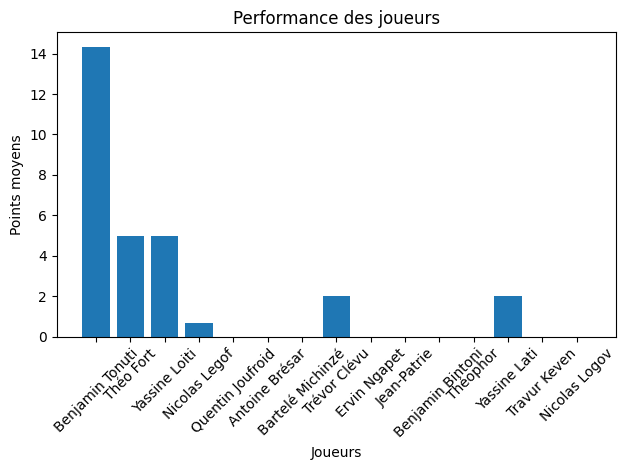

In [ ]:
# =========================
# 📊 VISUALISATION
# =========================

players_db = load_players_db()

players = list(players_db.keys())
avg_points = [players_db[p].get("avg_points", 0) for p in players]

plt.figure()
plt.bar(players, avg_points)

plt.xlabel("Joueurs")
plt.ylabel("Points moyens")
plt.title("Performance des joueurs")

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

## 📊 Documentation — Système de Notation

### Critères de notation (0-20)

| Critère | Calcul | Description |
|---------|--------|-------------|
| **Technique** | `(points + aces×2) - (erreurs×2)` | Maîtrise du geste et précision |
| **Défense** | `(blocks×3) - erreurs` | Capacité défensive et réactivité |
| **Attitude** | `20 - erreurs` | Cohérence et régularité |
| **Physique** | `(points + aces + blocks) / 2` | Intensité et fréquence d'actions |
| **Décision Tactique** | `(points×2) / (points + erreurs + blocks) × 20` | Efficacité des choix tactiques |

**Score final** = Moyenne des 5 critères (arrondie à 1 décimale)

### Exemple de structure JSON pour un joueur :

```json
{
  "name": "Jean Dupont",
  "team": "A",
  "points": 15,
  "aces": 2,
  "blocks": 3,
  "errors": 4,
  "scores": {
    "technique": 18.5,
    "defense": 16.0,
    "attitude": 16.0,
    "physique": 12.0,
    "decision_tactique": 17.1
  },
  "final_score": 15.9,
  "notes": "Bon joueur avec une technique solide et une excellente défense..."
}
```
